In [49]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import PassiveAggressiveClassifier

# Evaluation
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report
)

# Save Model
import pickle

In [50]:
true=pd.read_csv('True.csv/True.csv')
fake=pd.read_csv('Fake.csv/Fake.csv')

In [51]:
true=pd.DataFrame(true)
fake=pd.DataFrame(fake)

fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [52]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [53]:
print(fake.info())
print(true.info())

<class 'pandas.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    23481 non-null  str  
 1   text     23481 non-null  str  
 2   subject  23481 non-null  str  
 3   date     23481 non-null  str  
dtypes: str(4)
memory usage: 60.4 MB
None
<class 'pandas.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    21417 non-null  str  
 1   text     21417 non-null  str  
 2   subject  21417 non-null  str  
 3   date     21417 non-null  str  
dtypes: str(4)
memory usage: 51.6 MB
None


In [54]:
print(true.shape)
print(fake.shape)

(21417, 4)
(23481, 4)


In [55]:
print(fake.isnull().sum())
print(true.isnull().sum())


title      0
text       0
subject    0
date       0
dtype: int64
title      0
text       0
subject    0
date       0
dtype: int64


In [56]:
print(fake.duplicated().sum())
print(true.duplicated().sum())

3
206


In [57]:
fake["label"] = 0
true["label"] = 1
df = pd.concat([fake, true], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [58]:
df.duplicated().sum()

np.int64(209)

In [59]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [60]:
df["content"] = df["title"] + " " + df["text"]

In [61]:
print(df.shape)
print(df.info())

(44689, 6)
<class 'pandas.DataFrame'>
Index: 44689 entries, 0 to 44897
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44689 non-null  str  
 1   text     44689 non-null  str  
 2   subject  44689 non-null  str  
 3   date     44689 non-null  str  
 4   label    44689 non-null  int64
 5   content  44689 non-null  str  
dtypes: int64(1), str(5)
memory usage: 221.4 MB
None


In [62]:
df.label.value_counts()

label
0    23478
1    21211
Name: count, dtype: int64

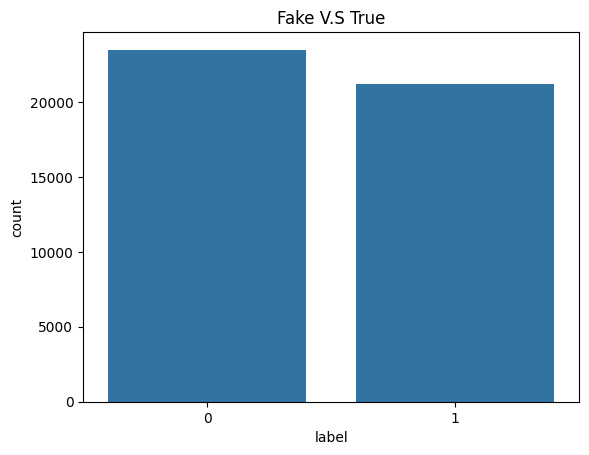

In [63]:
sns.countplot(x='label', data=df)
plt.title('Fake V.S True')
plt.show()

In [64]:
df['date']=pd.to_datetime(df['date'],errors='coerce')
df.info()

<class 'pandas.DataFrame'>
Index: 44689 entries, 0 to 44897
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   title    44689 non-null  str           
 1   text     44689 non-null  str           
 2   subject  44689 non-null  str           
 3   date     11868 non-null  datetime64[us]
 4   label    44689 non-null  int64         
 5   content  44689 non-null  str           
dtypes: datetime64[us](1), int64(1), str(4)
memory usage: 220.8 MB


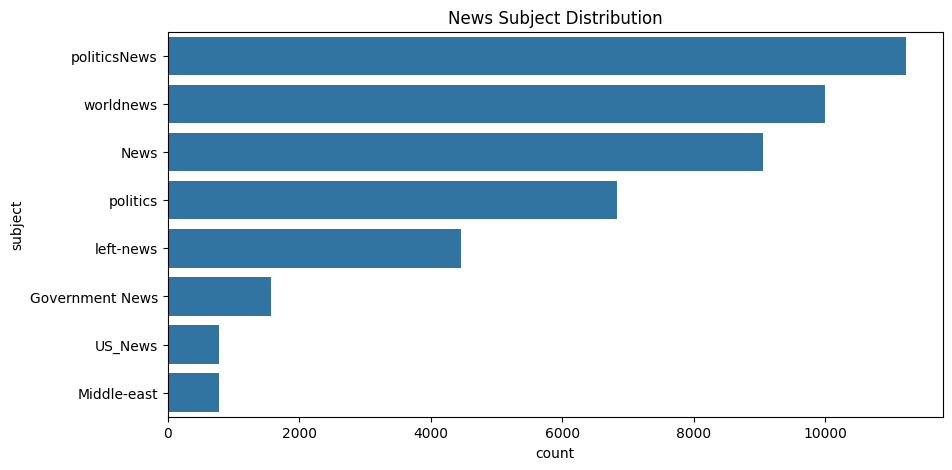

In [65]:
plt.figure(figsize=(10,5))
sns.countplot(y="subject",data=df,order=df["subject"].value_counts().index)
plt.title("News Subject Distribution")
plt.show()

In [66]:
df["text_length"] = df["text"].apply(len)
df["text_length"].describe()

count    44689.000000
mean      2467.098682
std       2173.612347
min          1.000000
25%       1232.000000
50%       2185.000000
75%       3101.000000
max      51794.000000
Name: text_length, dtype: float64

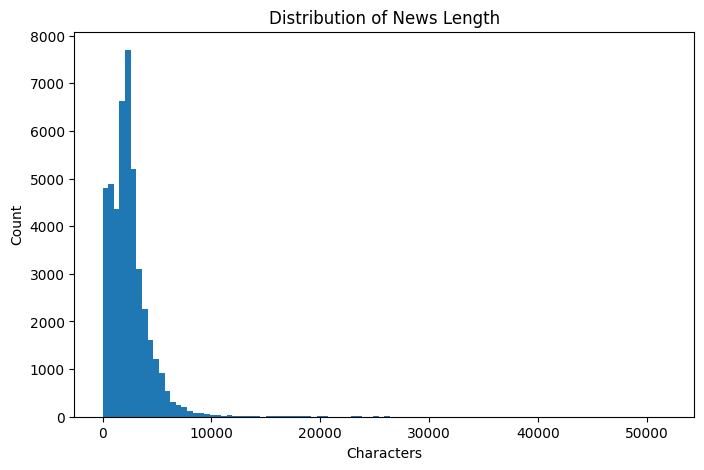

In [67]:
plt.figure(figsize=(8,5))
plt.hist(df["text_length"], bins=100)
plt.title("Distribution of News Length")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.show()

In [68]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kunal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [69]:
ps=PorterStemmer()
stop_words=set(stopwords.words('english'))

In [70]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r'[^a-zA-Z]', ' ',text)
    words=text.split()
    words=[ps.stem(word)for word in words if word not in stop_words]
    return " ".join(words)


In [71]:
sample = "The Prime Minister visited India in 2024!!"

print(clean_text(sample))

prime minist visit india


In [72]:
df["clean_text"] = df["content"].apply(clean_text)

In [73]:
df[["title", "text", "clean_text"]].head()

,title,text,clean_text
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",ben stein call th circuit court commit coup ta...
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,trump drop steve bannon nation secur council w...
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,puerto rico expect u lift jone act ship restri...
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",oop trump accident confirm leak isra intellig ...
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",donald trump head scotland reopen golf resort ...


In [74]:
df.head()

,title,text,subject,date,label,content,text_length,clean_text
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,2017-02-13,0,Ben Stein Calls Out 9th Circuit Court: Committ...,1028,ben stein call th circuit court commit coup ta...
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,NaT,1,Trump drops Steve Bannon from National Securit...,4820,trump drop steve bannon nation secur council w...
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,NaT,1,Puerto Rico expects U.S. to lift Jones Act shi...,1848,puerto rico expect u lift jone act ship restri...
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,2017-05-22,0,OOPS: Trump Just Accidentally Confirmed He Le...,1244,oop trump accident confirm leak isra intellig ...
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,NaT,1,Donald Trump heads for Scotland to reopen a go...,3137,donald trump head scotland reopen golf resort ...


In [75]:
X = df["clean_text"]
y = df["label"]

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

In [77]:
tfidf = TfidfVectorizer(max_features=10000,ngram_range=(1,2))
X_train=tfidf.fit_transform(X_train)
X_test=tfidf.transform(X_test)

In [78]:
print(X_train.shape)
print(X_test.shape)

(35751, 10000)
(8938, 10000)


In [79]:
lr=LogisticRegression()

In [80]:
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [81]:
Y_pred=lr.predict(X_test)
Y_pred

array([1, 0, 0, ..., 0, 0, 0], shape=(8938,))

In [82]:
accuracy_score(y_test, Y_pred)*100

98.94831058402328

In [83]:
confusion_matrix(y_test, Y_pred)

array([[4589,   63],
       [  31, 4255]])

In [84]:
print(classification_report(y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4652
           1       0.99      0.99      0.99      4286

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



In [85]:
pac=PassiveAggressiveClassifier(random_state=42)

C:\Users\kunal\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


In [86]:
pac.fit(X_train, y_train)
y_pred_pac = pac.predict(X_test)

In [87]:
accuracy_score(y_test, y_pred_pac) * 100

99.64197807115686

In [88]:
print(classification_report(y_test, y_pred_pac))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4652
           1       1.00      1.00      1.00      4286

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



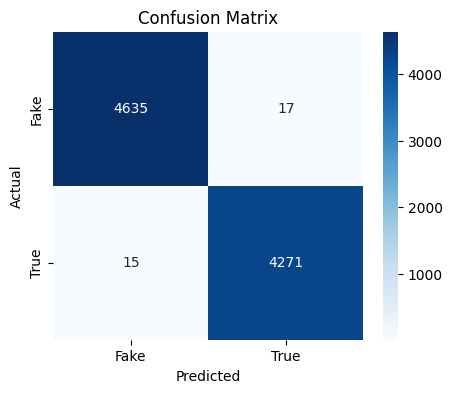

In [89]:
cm = confusion_matrix(y_test, y_pred_pac)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Fake","True"], yticklabels=["Fake","True"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

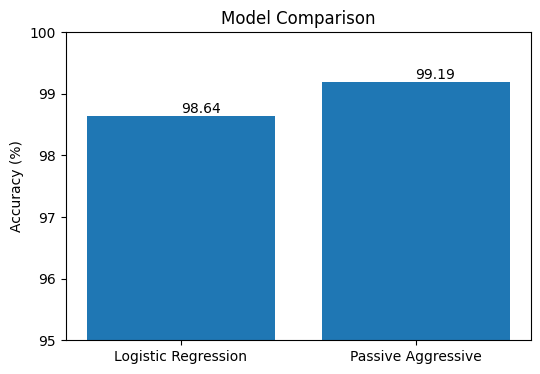

In [90]:
models = ["Logistic Regression", "Passive Aggressive"]
accuracy = [98.64, 99.19]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison")
plt.ylim(95,100)

for i, v in enumerate(accuracy):
    plt.text(i, v+0.05, str(v))

plt.show()

In [91]:
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("model", PassiveAggressiveClassifier(random_state=42))
])

C:\Users\kunal\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


In [92]:
pipe.fit(X,y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [93]:
import pickle

with open("fake_news_model.pkl", "wb") as f:
    pickle.dump(pipe, f)

In [94]:
with open("fake_news_model.pkl", "rb") as f:
    model = pickle.load(f)

C:\Users\kunal\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


In [95]:
news = [
    "Donald Trump announces new economic policy."
]

prediction = model.predict(news)

print(prediction)

[1]
